Found 18000 images belonging to 20 classes.
Found 6000 images belonging to 20 classes.


C:\Users\Varshitha Agraharam\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │           2,580 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 685,780 (2.62 MB)

 Trainable params: 685,780 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 640s 1s/step - accuracy: 0.9463 - loss: 0.1700 - val_accuracy: 0.9997 - val_loss: 0.0014
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 102s 180ms/step - accuracy: 0.9923 - loss: 0.0223 - val_accuracy: 1.0000 - val_loss: 2.4144e-04
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 97s 101ms/step - accuracy: 0.9942 - loss: 0.0145 - val_accuracy: 0.9998 - val_loss: 0.0016
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 74s 131ms/step - accuracy: 0.9964 - loss: 0.0096 - val_accuracy: 1.0000 - val_loss: 1.4387e-05
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 63s 96ms/step - accuracy: 0.9971 - loss: 0.0098 - val_accuracy: 1.0000 - val_loss: 9.7696e-05
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 46s 81ms/step - accuracy: 0.9979 - loss: 0.0063 - val_accuracy: 0.9998 - val_loss: 4.3701e-04
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 48s 86ms/step - accuracy: 0.9981 - loss: 0.0056 - val_accuracy: 0.9998 - val_loss: 0.0020
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 49s 87ms/step - accuracy: 0.998

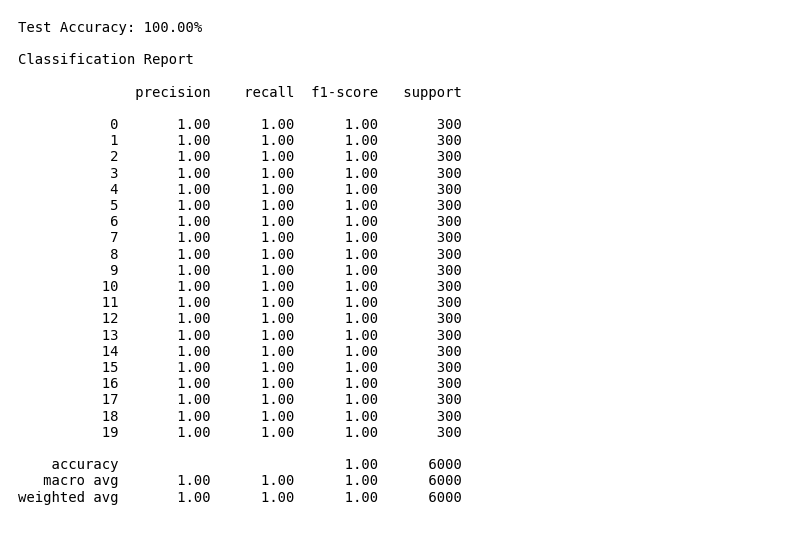

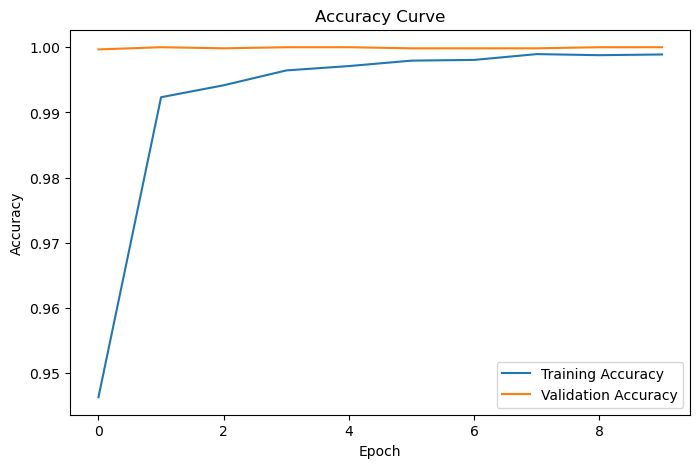

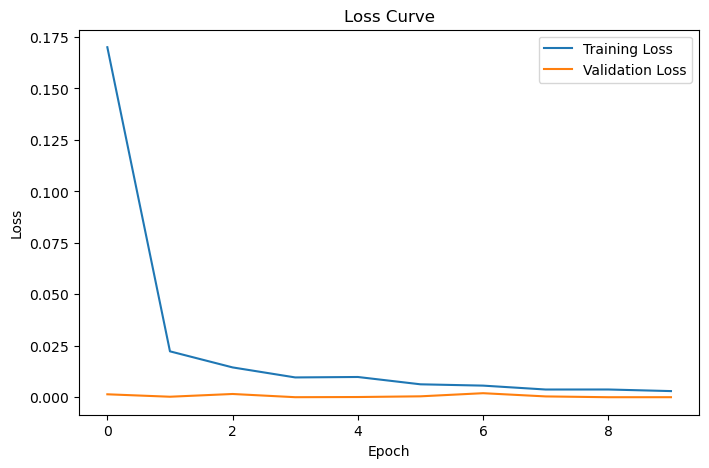

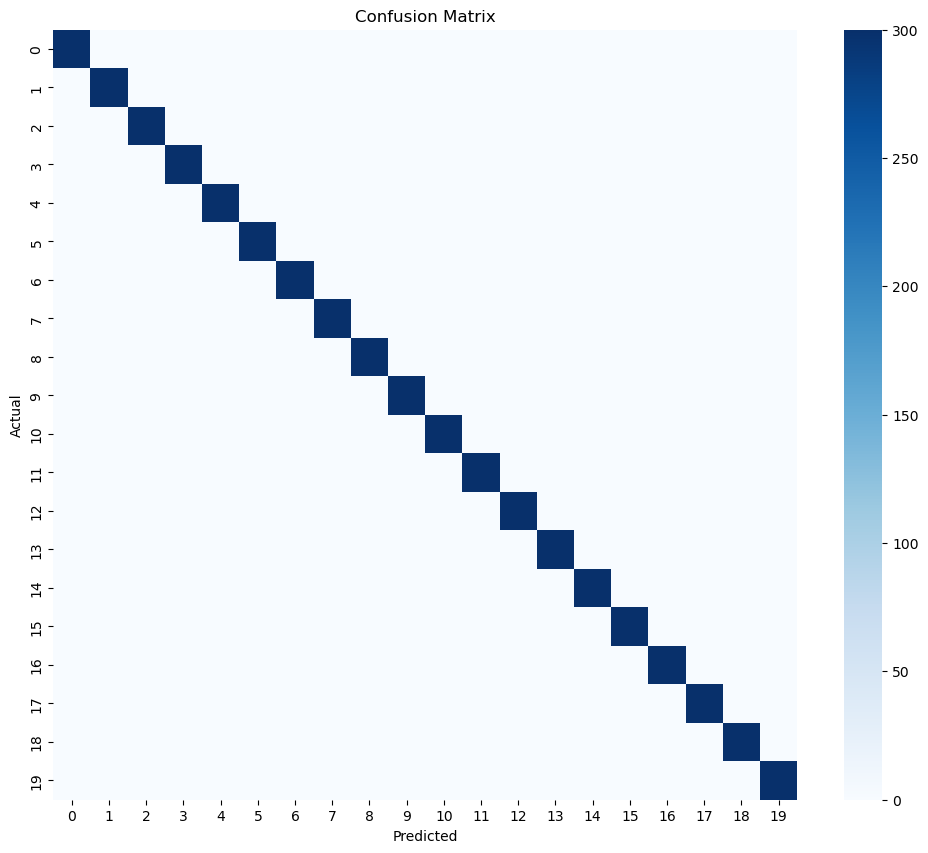

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


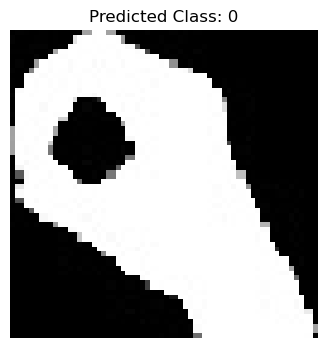


Model saved successfully!


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# CREATE OUTPUT FOLDER
# ==========================================

os.makedirs("outputs", exist_ok=True)

# ==========================================
# DATASET PATHS
# ==========================================

train_dir = "train/train"
test_dir = "test/test"

# ==========================================
# IMAGE GENERATORS
# ==========================================

train_gen = ImageDataGenerator(
    rescale=1./255
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ==========================================
# CNN MODEL
# ==========================================

model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(20, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==========================================
# TRAIN MODEL
# ==========================================

history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

# ==========================================
# EVALUATE MODEL
# ==========================================

loss, accuracy = model.evaluate(test_data)

print("\nTest Accuracy:", accuracy)

# ==========================================
# SAVE ACCURACY & REPORT
# ==========================================

predictions = model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

report = classification_report(y_true, y_pred)

plt.figure(figsize=(10,7))
plt.axis("off")

plt.text(
    0.01,
    0.98,
    f"Test Accuracy: {accuracy:.2%}\n\nClassification Report\n\n{report}",
    fontsize=10,
    verticalalignment='top',
    family='monospace'
)

plt.savefig(
    "outputs/model_performance.png",
    bbox_inches="tight"
)

plt.show()

# ==========================================
# ACCURACY CURVE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.savefig("outputs/accuracy_curve.png")

plt.show()

# ==========================================
# LOSS CURVE
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.savefig("outputs/loss_curve.png")

plt.show()

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("outputs/confusion_matrix.png")

plt.show()

# ==========================================
# SAMPLE PREDICTION
# ==========================================

images, labels = next(test_data)

sample = images[0]

prediction = model.predict(
    np.expand_dims(sample, axis=0)
)

predicted_class = np.argmax(prediction)

plt.figure(figsize=(4,4))

plt.imshow(sample)

plt.title(
    f"Predicted Class: {predicted_class}"
)

plt.axis("off")

plt.savefig("outputs/sample_prediction.png")

plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

model.save("hand_gesture_model.h5")

print("\nModel saved successfully!")